Name : Hari Krishnan

Dataset Source: https://archive.ics.uci.edu/datasets


Q1.
Auto MPG Dataset (Fuel Efficiency Prediction)
Description: This dataset contains information on different car models, including engine
displacement, horsepower, weight, acceleration, and miles per gallon (MPG).
Linear Regression Questions:
a. Develop a linear regression model to predict MPG based on horsepower. Evaluate its
accuracy using RMSE and Adjusted R-squared.
b. Check whether adding interaction terms (e.g., horsepower × weight) improves model
accuracy.
c. Conduct a hypothesis test to determine if weight has a significant impact on fuel
efficiency.
Polynomial Regression Questions:
d. Fit a quadratic and cubic regression model to predict MPG based on horsepower.
Compare model performance using cross-validation.
e. Visualize the polynomial regression curves and discuss whether higher-degree models
lead to overfitting

<ipython-input-29-b85723ad0c9d>:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  auto_mpg = pd.read_csv(url, delim_whitespace=True, names=column_names, na_values='?')


First 5 rows of the dataset:
    MPG  Cylinders  Displacement  Horsepower  Weight  Acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   Model Year  Origin                   Car Name  
0          70       1  chevrolet chevelle malibu  
1          70       1          buick skylark 320  
2          70       1         plymouth satellite  
3          70       1              amc rebel sst  
4          70       1                ford torino  

Q1a: Linear Regression to Predict MPG based on Horsepower
RMSE: 4.89
Adjusted R-squared: 0.60

Q1b: Adding Interaction Terms
RMSE with interaction term: 3.91
Adjusted R-squared with interaction term: 0.75

Q1c: Hypothesis Test for Weight's Imp

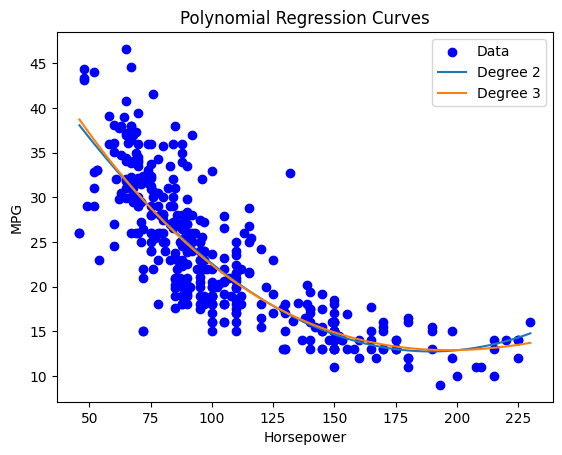

Higher-degree models (e.g., cubic) may lead to overfitting if they capture noise in the data. Cross-validation helps assess this.

Analysis Complete!


In [29]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from scipy import stats

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year', 'Origin', 'Car Name']
auto_mpg = pd.read_csv(url, delim_whitespace=True, names=column_names, na_values='?')

# Drop rows with missing values
auto_mpg.dropna(inplace=True)

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
print(auto_mpg.head())

# Q1a: Linear Regression to Predict MPG based on Horsepower
print("\n" + "="*50)
print("Q1a: Linear Regression to Predict MPG based on Horsepower")
print("="*50)

# Prepare data
X = auto_mpg[['Horsepower']]
y = auto_mpg['MPG']

# Fit linear regression model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Evaluate model
rmse = np.sqrt(mean_squared_error(y, y_pred))
adj_r2 = 1 - (1 - r2_score(y, y_pred)) * (len(y) - 1) / (len(y) - X.shape[1] - 1)
print(f"RMSE: {rmse:.2f}")
print(f"Adjusted R-squared: {adj_r2:.2f}")

# Q1b: Adding Interaction Terms
print("\n" + "="*50)
print("Q1b: Adding Interaction Terms")
print("="*50)

# Create interaction term: Horsepower × Weight
auto_mpg['Horsepower_Weight'] = auto_mpg['Horsepower'] * auto_mpg['Weight']

# Fit new model with interaction term
X_interaction = auto_mpg[['Horsepower', 'Weight', 'Horsepower_Weight']]
model_interaction = LinearRegression()
model_interaction.fit(X_interaction, y)
y_pred_interaction = model_interaction.predict(X_interaction)

# Evaluate new model
rmse_interaction = np.sqrt(mean_squared_error(y, y_pred_interaction))
adj_r2_interaction = 1 - (1 - r2_score(y, y_pred_interaction)) * (len(y) - 1) / (len(y) - X_interaction.shape[1] - 1)
print(f"RMSE with interaction term: {rmse_interaction:.2f}")
print(f"Adjusted R-squared with interaction term: {adj_r2_interaction:.2f}")

# Q1c: Hypothesis Test for Weight's Impact on MPG
print("\n" + "="*50)
print("Q1c: Hypothesis Test for Weight's Impact on MPG")
print("="*50)

# Fit a linear regression model with weight as the predictor
X_weight = auto_mpg[['Weight']]
model_weight = LinearRegression()
model_weight.fit(X_weight, y)

# Extract the coefficient for weight
weight_coef = model_weight.coef_[0]
print(f"Coefficient for Weight: {weight_coef:.2f}")

# Perform a t-test to check significance
t_stat, p_value = stats.ttest_1samp(auto_mpg['Weight'], 0)
print(f"T-statistic: {t_stat:.2f}, P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject the null hypothesis: Weight has a significant impact on MPG.")
else:
    print("Fail to reject the null hypothesis: Weight does not have a significant impact on MPG.")

# Q1d: Polynomial Regression
print("\n" + "="*50)
print("Q1d: Polynomial Regression")
print("="*50)

# Fit quadratic and cubic regression models
degrees = [2, 3]
results = {}

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    model_poly = LinearRegression()
    scores = cross_val_score(model_poly, X_poly, y, cv=5, scoring='neg_mean_squared_error')
    rmse_cv = np.sqrt(-scores.mean())
    results[degree] = rmse_cv
    print(f"Degree {degree} - Cross-validated RMSE: {rmse_cv:.2f}")

# Q1e: Visualize Polynomial Regression Curves
print("\n" + "="*50)
print("Q1e: Visualize Polynomial Regression Curves")
print("="*50)

# Plot the data
plt.scatter(X, y, color='blue', label='Data')

# Fit and plot polynomial regression curves
X_test = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_test = poly.fit_transform(X_test)
    model_poly = LinearRegression()
    model_poly.fit(poly.fit_transform(X), y)
    y_test = model_poly.predict(X_poly_test)
    plt.plot(X_test, y_test, label=f'Degree {degree}')

plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('Polynomial Regression Curves')
plt.legend()
plt.show()

# Discuss overfitting
print("Higher-degree models (e.g., cubic) may lead to overfitting if they capture noise in the data. Cross-validation helps assess this.")

print("\n" + "="*50)
print("Analysis Complete!")
print("="*50)

Q2.
Concrete Strength Dataset
Description: This dataset contains information on the compressive strength of concrete
based on different material compositions such as cement, water, and fine aggregate.
Linear Regression Questions:
a. Build a multiple linear regression model to predict concrete strength. Identify which
material has the most impact on the strength.
b. Analyze the residuals to check for normality and homoscedasticity.
c. Use a log-transformed regression model if the relationship between predictors and
response variable is non-linear.
Polynomial Regression Questions:
d. Fit a polynomial regression model to predict strength using cement and water.
Evaluate the polynomial degree that minimizes RMSE.
e. Compare the AIC/BIC values of linear and polynomial regression models to determine
the better-fitting model

First 5 rows of the dataset:
   Cement  Blast_Furnace_Slag  Fly_Ash  Water  Superplasticizer  \
0   540.0                 0.0      0.0  162.0               2.5   
1   540.0                 0.0      0.0  162.0               2.5   
2   332.5               142.5      0.0  228.0               0.0   
3   332.5               142.5      0.0  228.0               0.0   
4   198.6               132.4      0.0  192.0               0.0   

   Coarse_Aggregate  Fine_Aggregate  Age  Compressive_Strength  
0            1040.0           676.0   28             79.986111  
1            1055.0           676.0   28             61.887366  
2             932.0           594.0  270             40.269535  
3             932.0           594.0  365             41.052780  
4             978.4           825.5  360             44.296075  

Q2a: Multiple Linear Regression
RMSE: 10.35
Coefficients for each material:
Superplasticizer      0.290687
Cement                0.119785
Age                   0.114226
Blast_Fu

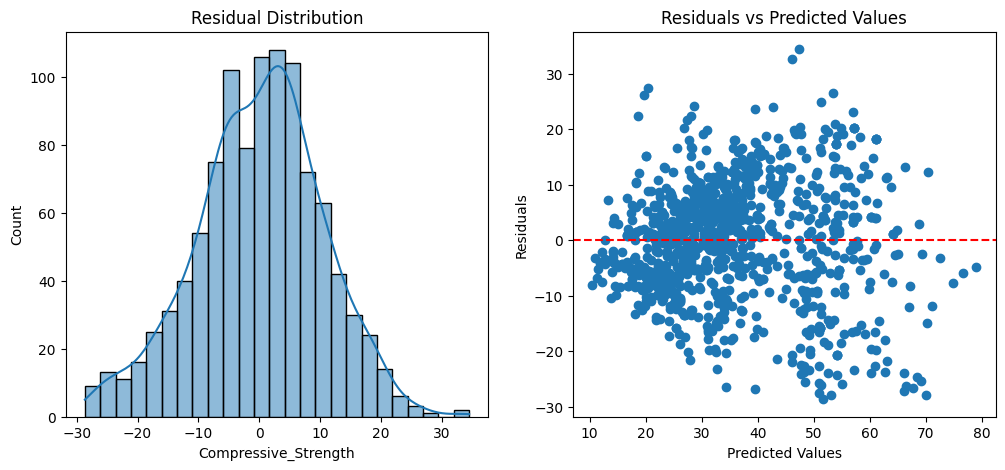


Q2c: Log-Transformed Regression
RMSE of log-transformed model: 0.37

Q2d: Polynomial Regression
Degree 1 - RMSE: 13.87
Degree 2 - RMSE: 13.59
Degree 3 - RMSE: 13.18

Q2e: Compare AIC/BIC Values
Linear Model - AIC: 4833.05, BIC: 4877.49
Polynomial Model (Degree 2) - AIC: 5332.56, BIC: 5381.93
Linear model is better based on AIC.
Linear model is better based on BIC.

Analysis Complete!


In [30]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from scipy import stats
import statsmodels.api as sm
from statsmodels.tools.eval_measures import aicc, bic

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
concrete = pd.read_excel(url)

# Rename columns for clarity
concrete.columns = ['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer',
                    'Coarse_Aggregate', 'Fine_Aggregate', 'Age', 'Compressive_Strength']

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
print(concrete.head())

# Q2a: Multiple Linear Regression
print("\n" + "="*50)
print("Q2a: Multiple Linear Regression")
print("="*50)

# Prepare data
X = concrete.drop('Compressive_Strength', axis=1)
y = concrete['Compressive_Strength']

# Fit multiple linear regression model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Evaluate model
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"RMSE: {rmse:.2f}")

# Identify the most impactful material
coefficients = pd.Series(model.coef_, index=X.columns)
print("Coefficients for each material:")
print(coefficients.sort_values(ascending=False))

# Q2b: Residual Analysis
print("\n" + "="*50)
print("Q2b: Residual Analysis")
print("="*50)

# Calculate residuals
residuals = y - y_pred

# Check for normality
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")

# Check for homoscedasticity
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

# Q2c: Log-Transformed Regression
print("\n" + "="*50)
print("Q2c: Log-Transformed Regression")
print("="*50)

# Apply log transformation to the response variable
y_log = np.log(y)

# Fit log-transformed regression model
model_log = LinearRegression()
model_log.fit(X, y_log)
y_pred_log = model_log.predict(X)

# Evaluate log-transformed model
rmse_log = np.sqrt(mean_squared_error(y_log, y_pred_log))
print(f"RMSE of log-transformed model: {rmse_log:.2f}")

# Q2d: Polynomial Regression
print("\n" + "="*50)
print("Q2d: Polynomial Regression")
print("="*50)

# Prepare data for polynomial regression
X_poly = concrete[['Cement', 'Water']]
y_poly = concrete['Compressive_Strength']

# Fit polynomial regression models
degrees = [1, 2, 3]
results = {}

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_transformed = poly.fit_transform(X_poly)
    model_poly = LinearRegression()
    model_poly.fit(X_poly_transformed, y_poly)
    y_pred_poly = model_poly.predict(X_poly_transformed)
    rmse_poly = np.sqrt(mean_squared_error(y_poly, y_pred_poly))
    results[degree] = rmse_poly
    print(f"Degree {degree} - RMSE: {rmse_poly:.2f}")

# Q2e: Compare AIC/BIC Values
print("\n" + "="*50)
print("Q2e: Compare AIC/BIC Values")
print("="*50)

# Function to calculate AIC and BIC
def calculate_aic_bic(model, X, y):
    n = len(y)
    k = X.shape[1]
    y_pred = model.predict(X)
    rss = np.sum((y - y_pred) ** 2)
    aic = n * np.log(rss / n) + 2 * k
    bic = n * np.log(rss / n) + k * np.log(n)
    return aic, bic

# Compare linear and polynomial models
X_linear = sm.add_constant(X)
linear_model = sm.OLS(y, X_linear).fit()
aic_linear, bic_linear = calculate_aic_bic(linear_model, X_linear, y)

X_poly_2 = sm.add_constant(poly.fit_transform(X_poly))
poly_model = sm.OLS(y_poly, X_poly_2).fit()
aic_poly, bic_poly = calculate_aic_bic(poly_model, X_poly_2, y_poly)

print(f"Linear Model - AIC: {aic_linear:.2f}, BIC: {bic_linear:.2f}")
print(f"Polynomial Model (Degree 2) - AIC: {aic_poly:.2f}, BIC: {bic_poly:.2f}")

if aic_poly < aic_linear:
    print("Polynomial model is better based on AIC.")
else:
    print("Linear model is better based on AIC.")

if bic_poly < bic_linear:
    print("Polynomial model is better based on BIC.")
else:
    print("Linear model is better based on BIC.")

print("\n" + "="*50)
print("Analysis Complete!")
print("="*50)

Q3.
Bike Sharing Dataset
Description: This dataset contains information on the number of bike rentals based on
weather, temperature, humidity, and time-related variables.
Linear Regression Questions:
a. Construct a time-series linear regression model to predict bike rentals based on
temperature and humidity.
b. Include categorical variables such as "weekday" and "holiday" using one-hot encoding
in a multiple regression model.
Polynomial Regression Questions:
c. Fit a polynomial regression model to understand the relationship between bike rentals
and temperature. Determine whether a quadratic or cubic model provides a better fit.
d. Plot learning curves to examine whether the polynomial regression model is
overfitting or underfitting the data.

First 5 rows of the dataset:
   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600

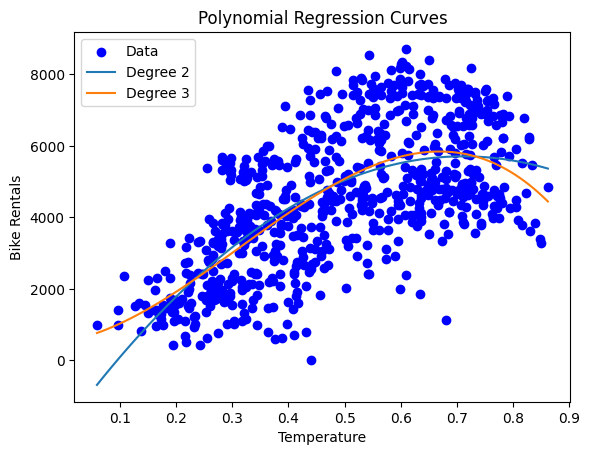


Q3d: Learning Curves


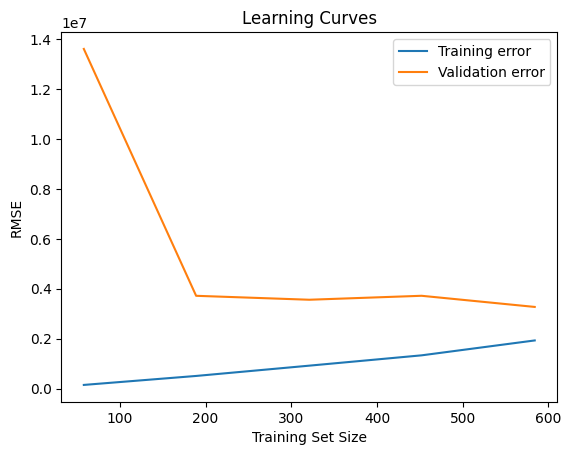


Analysis Complete!


In [31]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip"
# Download and extract the dataset manually, then load it
bike = pd.read_csv("day.csv")

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
print(bike.head())

# Q3a: Time-Series Linear Regression
print("\n" + "="*50)
print("Q3a: Time-Series Linear Regression")
print("="*50)

# Prepare data
X = bike[['temp', 'hum']]
y = bike['cnt']

# Fit linear regression model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Evaluate model
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"RMSE: {rmse:.2f}")

# Q3b: Multiple Regression with Categorical Variables
print("\n" + "="*50)
print("Q3b: Multiple Regression with Categorical Variables")
print("="*50)

# Prepare data
X = bike[['temp', 'hum', 'weekday', 'holiday']]
y = bike['cnt']

# One-hot encode categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), ['weekday', 'holiday'])
    ],
    remainder='passthrough'
)

# Fit multiple regression model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
model.fit(X, y)
y_pred = model.predict(X)

# Evaluate model
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"RMSE with categorical variables: {rmse:.2f}")

# Q3c: Polynomial Regression
print("\n" + "="*50)
print("Q3c: Polynomial Regression")
print("="*50)

# Prepare data
X = bike[['temp']]
y = bike['cnt']

# Fit polynomial regression models
degrees = [2, 3]
results = {}
models = {}  # Store models for each degree

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    model_poly = LinearRegression()
    model_poly.fit(X_poly, y)
    y_pred_poly = model_poly.predict(X_poly)
    rmse_poly = np.sqrt(mean_squared_error(y, y_pred_poly))
    results[degree] = rmse_poly
    models[degree] = model_poly  # Store the model
    print(f"Degree {degree} - RMSE: {rmse_poly:.2f}")

# Plot polynomial regression curves
plt.scatter(X, y, color='blue', label='Data')
X_test = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_test = poly.fit_transform(X_test)
    # Use the correct model for prediction
    y_test = models[degree].predict(X_poly_test)
    plt.plot(X_test, y_test, label=f'Degree {degree}')

plt.xlabel('Temperature')
plt.ylabel('Bike Rentals')
plt.title('Polynomial Regression Curves')
plt.legend()
plt.show()

# Q3d: Learning Curves
print("\n" + "="*50)
print("Q3d: Learning Curves")
print("="*50)

# Function to plot learning curves
def plot_learning_curve(model, X, y):
    train_sizes, train_scores, test_scores = learning_curve(model, X, y, cv=5, scoring='neg_mean_squared_error')
    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)

    plt.plot(train_sizes, train_scores_mean, label='Training error')
    plt.plot(train_sizes, test_scores_mean, label='Validation error')
    plt.xlabel('Training Set Size')
    plt.ylabel('RMSE')
    plt.title('Learning Curves')
    plt.legend()
    plt.show()

# Plot learning curves for polynomial regression (degree 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
model_poly = LinearRegression()
plot_learning_curve(model_poly, X_poly, y)

print("\n" + "="*50)
print("Analysis Complete!")
print("="*50)

Q4.
Energy Efficiency Dataset (Building Energy Consumption Prediction)
Description: This dataset contains information on building characteristics, such as wall
area, roof area, and glazing area, to predict energy efficiency.
Linear Regression Questions:
a. Develop a multiple linear regression model to predict heating load based on
building characteristics.
b. Analyze feature importance using standardized regression coefficients.
c. Detect outliers using the Cook’s distance method and analyze their impact on the
model.
Polynomial Regression Questions:
d. Fit a polynomial regression model to capture nonlinear relationships between
heating load and glazing area.
e. Compare linear vs. polynomial models using cross-validation and interpret the
results.

First 5 rows of the dataset:
   Relative_Compactness  Surface_Area  Wall_Area  Roof_Area  Overall_Height  \
0                  0.98         514.5      294.0     110.25             7.0   
1                  0.98         514.5      294.0     110.25             7.0   
2                  0.98         514.5      294.0     110.25             7.0   
3                  0.98         514.5      294.0     110.25             7.0   
4                  0.90         563.5      318.5     122.50             7.0   

   Orientation  Glazing_Area  Glazing_Area_Distribution  Heating_Load  \
0            2           0.0                          0         15.55   
1            3           0.0                          0         15.55   
2            4           0.0                          0         15.55   
3            5           0.0                          0         15.55   
4            2           0.0                          0         20.84   

   Cooling_Load  
0         21.33  
1         21.33  
2  

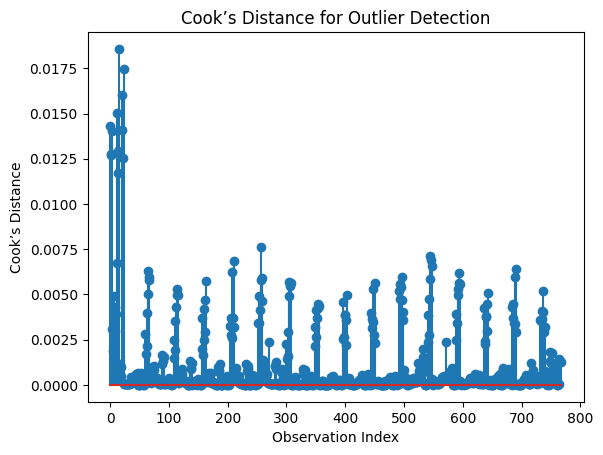

Outliers detected at indices: [  0   1   2   3  11  12  13  14  15  20  21  22  23  65  66  67 113 163
 208 211 256 257 258 305 306 307 448 451 494 495 496 544 545 546 547 591
 593 594 595 688 691]
RMSE after removing outliers: 2.42

Q4d: Polynomial Regression
Degree 2 - RMSE: 9.69
Degree 3 - RMSE: 9.66


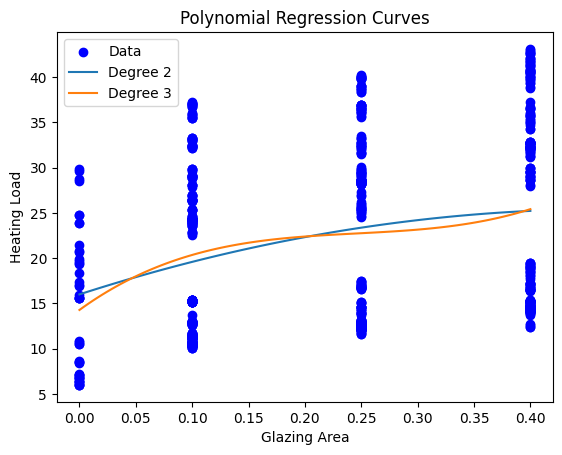


Q4e: Compare Linear vs. Polynomial Models using Cross-Validation
Linear Model - Cross-validated RMSE: 3.20
Polynomial Model (Degree 2) - Cross-validated RMSE: 9.79
Linear model performs better based on cross-validation.

Analysis Complete!


In [32]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
import statsmodels.api as sm # Import statsmodels.api
from statsmodels.stats.outliers_influence import OLSInfluence

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
energy = pd.read_excel(url)

# Rename columns for clarity
energy.columns = ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height',
                  'Orientation', 'Glazing_Area', 'Glazing_Area_Distribution', 'Heating_Load', 'Cooling_Load']

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
print(energy.head())

# Q4a: Multiple Linear Regression
print("\n" + "="*50)
print("Q4a: Multiple Linear Regression")
print("="*50)

# Prepare data
X = energy.drop(['Heating_Load', 'Cooling_Load'], axis=1)
y = energy['Heating_Load']

# Fit multiple linear regression model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Evaluate model
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"RMSE: {rmse:.2f}")

# Q4b: Feature Importance using Standardized Coefficients
print("\n" + "="*50)
print("Q4b: Feature Importance using Standardized Coefficients")
print("="*50)

# Standardize features
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

# Fit model with standardized features
model_standardized = LinearRegression()
model_standardized.fit(X_standardized, y)

# Extract standardized coefficients
coefficients = pd.Series(model_standardized.coef_, index=X.columns)
print("Standardized Coefficients:")
print(coefficients.sort_values(ascending=False))

# Q4c: Outlier Detection using Cook’s Distance
print("\n" + "="*50)
print("Q4c: Outlier Detection using Cook’s Distance")
print("="*50)

# Fit an OLS model for Cook's distance calculation
X_ols = sm.add_constant(X)  # Add a constant term to the predictor variables
model_ols = sm.OLS(y, X_ols).fit()  # Fit the OLS model using statsmodels

# Calculate Cook’s distance using the OLS model
influence = OLSInfluence(model_ols)  # Pass the OLS model to OLSInfluence
cooks_distance = influence.cooks_distance[0]

# Plot Cook’s distance
plt.stem(cooks_distance)
plt.title("Cook’s Distance for Outlier Detection")
plt.xlabel("Observation Index")
plt.ylabel("Cook’s Distance")
plt.show()

# Identify outliers
outliers = np.where(cooks_distance > 4 / len(X))[0]
print(f"Outliers detected at indices: {outliers}")

# Analyze impact of outliers
X_no_outliers = X.drop(outliers)
y_no_outliers = y.drop(outliers)
model_no_outliers = LinearRegression()
model_no_outliers.fit(X_no_outliers, y_no_outliers)
y_pred_no_outliers = model_no_outliers.predict(X_no_outliers)
rmse_no_outliers = np.sqrt(mean_squared_error(y_no_outliers, y_pred_no_outliers))
print(f"RMSE after removing outliers: {rmse_no_outliers:.2f}")

# Q4d: Polynomial Regression
print("\n" + "="*50)
print("Q4d: Polynomial Regression")
print("="*50)

# Prepare data
X_poly = energy[['Glazing_Area']]
y_poly = energy['Heating_Load']

# Fit polynomial regression models
degrees = [2, 3]
results = {}

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_transformed = poly.fit_transform(X_poly)
    model_poly = LinearRegression()
    model_poly.fit(X_poly_transformed, y_poly)
    y_pred_poly = model_poly.predict(X_poly_transformed)
    rmse_poly = np.sqrt(mean_squared_error(y_poly, y_pred_poly))
    results[degree] = rmse_poly
    print(f"Degree {degree} - RMSE: {rmse_poly:.2f}")

# Plot polynomial regression curves
plt.scatter(X_poly, y_poly, color='blue', label='Data')
X_test = np.linspace(X_poly.min(), X_poly.max(), 100).reshape(-1, 1)

# Store models for each degree
models = {}

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_transformed = poly.fit_transform(X_poly)
    model_poly = LinearRegression()
    model_poly.fit(X_poly_transformed, y_poly)
    models[degree] = model_poly  # Store the model

# Plot using the stored models
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_test = poly.fit_transform(X_test)
    y_test = models[degree].predict(X_poly_test)  # Use the correct model
    plt.plot(X_test, y_test, label=f'Degree {degree}')

plt.xlabel('Glazing Area')
plt.ylabel('Heating Load')
plt.title('Polynomial Regression Curves')
plt.legend()
plt.show()

# Q4e: Compare Linear vs. Polynomial Models using Cross-Validation
print("\n" + "="*50)
print("Q4e: Compare Linear vs. Polynomial Models using Cross-Validation")
print("="*50)

# Linear model cross-validation
linear_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
linear_rmse_cv = np.sqrt(-linear_scores.mean())
print(f"Linear Model - Cross-validated RMSE: {linear_rmse_cv:.2f}")

# Polynomial model cross-validation (degree 2)
poly = PolynomialFeatures(degree=2)
X_poly_transformed = poly.fit_transform(X_poly)
poly_scores = cross_val_score(model_poly, X_poly_transformed, y_poly, cv=5, scoring='neg_mean_squared_error')
poly_rmse_cv = np.sqrt(-poly_scores.mean())
print(f"Polynomial Model (Degree 2) - Cross-validated RMSE: {poly_rmse_cv:.2f}")

if poly_rmse_cv < linear_rmse_cv:
    print("Polynomial model performs better based on cross-validation.")
else:
    print("Linear model performs better based on cross-validation.")

print("\n" + "="*50)
print("Analysis Complete!")
print("="*50)

Q5.
Air Quality Dataset (Pollutant Level Prediction)
Description: This dataset contains air pollution data, including CO, NO2, O3, temperature,
and humidity.
Linear Regression Questions:
a. Construct a linear regression model to predict CO concentration based on
temperature and humidity.
b. Perform feature scaling (normalization vs. standardization) and evaluate its impact
on model performance.
c. Analyze the autocorrelation of residuals to check for time-series effects.
Polynomial Regression Questions:
d. Fit polynomial regression models of varying degrees to predict pollutant levels. Use
AIC/BIC for model selection.
e. Examine overfitting by plotting the polynomial regression curve and validation error.

First 5 rows of the dataset:
        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)   C6H6(GT)  \
0 2004-03-10  18:00:00     2.6      1360.00       150  11.881723   
1 2004-03-10  19:00:00     2.0      1292.25       112   9.397165   
2 2004-03-10  20:00:00     2.2      1402.00        88   8.997817   
3 2004-03-10  21:00:00     2.2      1375.50        80   9.228796   
4 2004-03-10  22:00:00     1.6      1272.25        51   6.518224   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0        1045.50    166.0       1056.25    113.0       1692.00      1267.50   
1         954.75    103.0       1173.75     92.0       1558.75       972.25   
2         939.25    131.0       1140.00    114.0       1554.50      1074.00   
3         948.25    172.0       1092.00    122.0       1583.75      1203.25   
4         835.50    131.0       1205.00    116.0       1490.00      1110.00   

       T         RH        AH  
0  13.60  48.875001  0.757754  
1  13.30  47.700000  0.

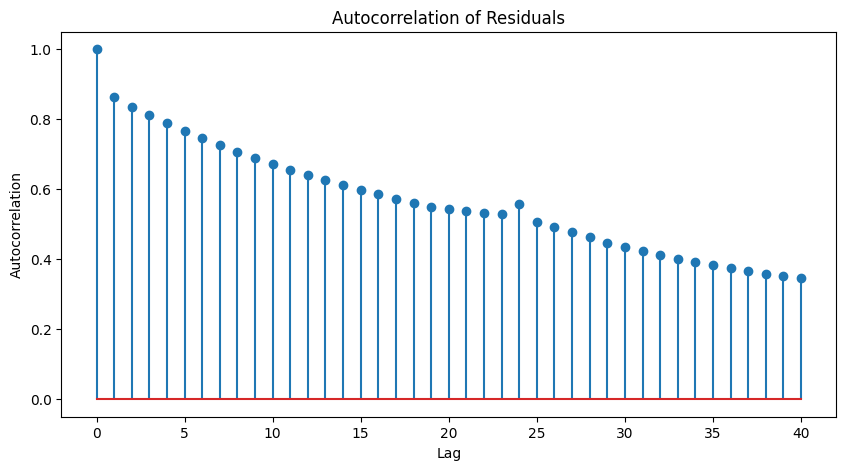


Q5d: Polynomial Regression with AIC/BIC for Model Selection
Degree 1 - RMSE: 77.47, AIC: 107961.44, BIC: 107975.73
Degree 2 - RMSE: 76.95, AIC: 107838.57, BIC: 107860.00
Degree 3 - RMSE: 76.82, AIC: 107809.16, BIC: 107837.73
Degree 4 - RMSE: 76.80, AIC: 107804.21, BIC: 107839.93
Best polynomial degree based on AIC: 4

Q5e: Overfitting Analysis


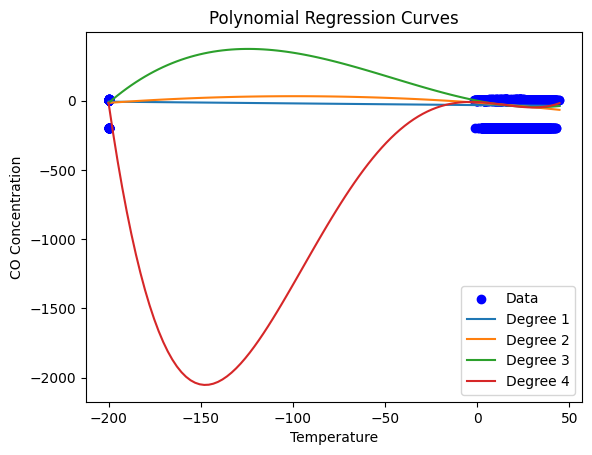

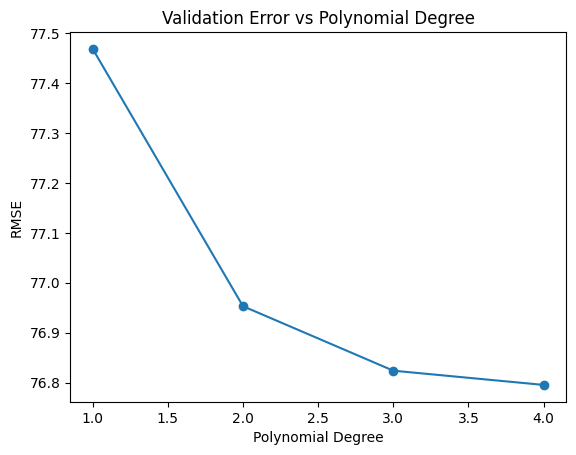


Analysis Complete!


In [33]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from statsmodels.tsa.stattools import acf
# Import aicc and bic directly from statsmodels.formula.api
from statsmodels.formula.api import ols
from sklearn.preprocessing import PolynomialFeatures

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip"
# Download and extract the dataset manually, then load it
air_quality = pd.read_excel("AirQualityUCI.xlsx")

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
print(air_quality.head())

# Clean the dataset (handle missing values, if any)
air_quality.dropna(inplace=True)

# Q5a: Linear Regression to Predict CO Concentration
print("\n" + "="*50)
print("Q5a: Linear Regression to Predict CO Concentration")
print("="*50)

# Prepare data
X = air_quality[['T', 'RH']]  # Temperature and Humidity
y = air_quality['CO(GT)']

# Fit linear regression model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Evaluate model
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"RMSE: {rmse:.2f}")

# Q5b: Feature Scaling (Normalization vs. Standardization)
print("\n" + "="*50)
print("Q5b: Feature Scaling (Normalization vs. Standardization)")
print("="*50)

# Normalization (Min-Max Scaling)
scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)
model_minmax = LinearRegression()
model_minmax.fit(X_minmax, y)
y_pred_minmax = model_minmax.predict(X_minmax)
rmse_minmax = np.sqrt(mean_squared_error(y, y_pred_minmax))
print(f"RMSE with Min-Max Scaling: {rmse_minmax:.2f}")

# Standardization (Z-score Scaling)
scaler_standard = StandardScaler()
X_standard = scaler_standard.fit_transform(X)
model_standard = LinearRegression()
model_standard.fit(X_standard, y)
y_pred_standard = model_standard.predict(X_standard)
rmse_standard = np.sqrt(mean_squared_error(y, y_pred_standard))
print(f"RMSE with Standardization: {rmse_standard:.2f}")

# Q5c: Autocorrelation of Residuals
print("\n" + "="*50)
print("Q5c: Autocorrelation of Residuals")
print("="*50)

# Calculate residuals
residuals = y - y_pred

# Plot autocorrelation of residuals
plt.figure(figsize=(10, 5))
acf_values = acf(residuals, nlags=40)
plt.stem(acf_values)
plt.title("Autocorrelation of Residuals")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

# Q5d: Polynomial Regression with AIC/BIC for Model Selection
print("\n" + "="*50)
print("Q5d: Polynomial Regression with AIC/BIC for Model Selection")
print("="*50)

# Prepare data
X_poly = air_quality[['T']]  # Temperature as predictor
y_poly = air_quality['CO(GT)']

# Fit polynomial regression models
degrees = [1, 2, 3, 4]
results = {}

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_transformed = poly.fit_transform(X_poly)
    model_poly = LinearRegression()
    model_poly.fit(X_poly_transformed, y_poly)
    y_pred_poly = model_poly.predict(X_poly_transformed)
    rmse_poly = np.sqrt(mean_squared_error(y_poly, y_pred_poly))

    # Create a DataFrame with individual columns for each polynomial term
    # This is the key change to fix the ValueError
    df_data = pd.DataFrame(X_poly_transformed, columns=[f'poly_{i}' for i in range(X_poly_transformed.shape[1])])
    df_data['y_poly'] = y_poly

    # Create a formula for ols using the new column names
    formula = 'y_poly ~ ' + ' + '.join(df_data.columns[:-1])

    # Fit the model using ols
    model_ols = ols(formula, data=df_data).fit()

    # Get AIC and BIC from the ols model
    aic = model_ols.aic
    bic_value = model_ols.bic

    results[degree] = {'RMSE': rmse_poly, 'AIC': aic, 'BIC': bic_value}
    print(f"Degree {degree} - RMSE: {rmse_poly:.2f}, AIC: {aic:.2f}, BIC: {bic_value:.2f}")

# Select the best model based on AIC/BIC
best_degree = min(results, key=lambda k: results[k]['AIC'])
print(f"Best polynomial degree based on AIC: {best_degree}")

# Q5e: Overfitting Analysis
print("\n" + "="*50)
print("Q5e: Overfitting Analysis")
print("="*50)

# Plot polynomial regression curves
plt.scatter(X_poly, y_poly, color='blue', label='Data')
X_test = np.linspace(X_poly.min(), X_poly.max(), 100).reshape(-1, 1)

# Store models for each degree (this part was already present in your code)
models = {}
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_transformed = poly.fit_transform(X_poly)
    model_poly = LinearRegression()
    model_poly.fit(X_poly_transformed, y_poly)
    models[degree] = model_poly  # Store the model

# Now use the stored models for prediction in the plotting loop:
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_test = poly.fit_transform(X_test)

    # Use the correct model for this degree from the 'models' dictionary
    y_test = models[degree].predict(X_poly_test)

    plt.plot(X_test, y_test, label=f'Degree {degree}')

plt.xlabel('Temperature')
plt.ylabel('CO Concentration')
plt.title('Polynomial Regression Curves')
plt.legend()
plt.show()

# Plot validation error
degrees_list = list(results.keys())
rmse_list = [results[d]['RMSE'] for d in degrees_list]
plt.plot(degrees_list, rmse_list, marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('Validation Error vs Polynomial Degree')
plt.show()

print("\n" + "="*50)
print("Analysis Complete!")
print("="*50)

Q6.
Parkinson’s Disease Dataset (Speech Signal Analysis for Diagnosis)
Description: This dataset includes voice measurements of individuals, which can be used
to predict Parkinson’s disease.
Linear Regression Questions:
a. Develop a linear regression model to predict a health index score based on vocal
attributes.
b. Identify the most significant vocal features affecting the prediction using p-values
and confidence intervals.
c. Check for heteroscedasticity using Breusch-Pagan test and propose a remedy if
heteroscedasticity is found.
Polynomial Regression Questions:
d. Fit a polynomial regression model to explore the nonlinear relationship between
voice jitter and health index.
e. Compare models using RMSE, Adjusted R², and visualize the polynomial curve.

First 5 rows of the dataset:
             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   
3  phon_R01_S01_4      116.676       137.871       111.366         0.00997   
4  phon_R01_S01_5      116.014       141.781       110.655         0.01284   

   MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  ...  \
0           0.00007   0.00370   0.00554     0.01109       0.04374  ...   
1           0.00008   0.00465   0.00696     0.01394       0.06134  ...   
2           0.00009   0.00544   0.00781     0.01633       0.05233  ...   
3           0.00009   0.00502   0.00698     0.01505       0.05492  ...   
4           0.00011   0.00655   0.00908     0.01966       0.06425  ...   

   Shimmer:DDA      NHR     HNR  status      RPDE       D

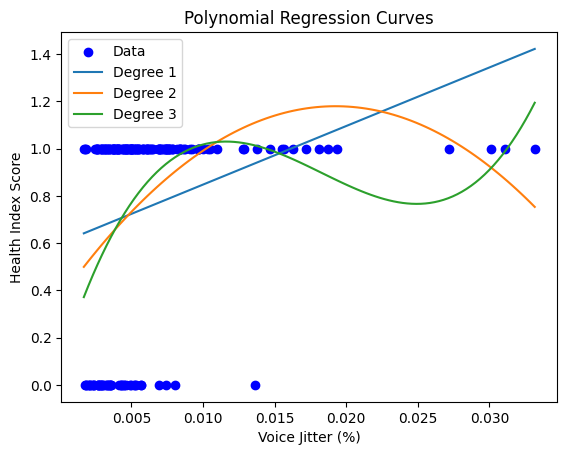

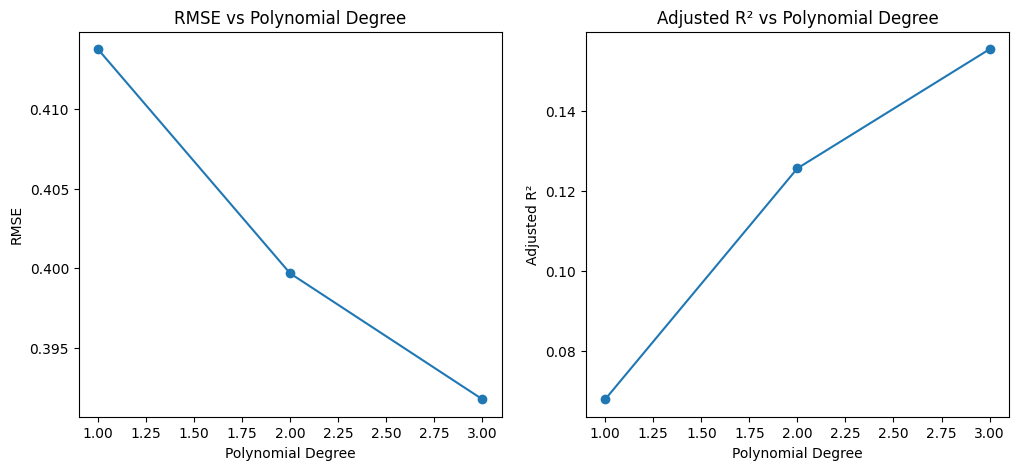


Analysis Complete!


In [34]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tools.eval_measures import aicc, bic

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data"
parkinsons = pd.read_csv(url)

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
print(parkinsons.head())

# Q6a: Linear Regression to Predict Health Index Score
print("\n" + "="*50)
print("Q6a: Linear Regression to Predict Health Index Score")
print("="*50)

# Prepare data
X = parkinsons.drop(['name', 'status'], axis=1)  # Exclude non-numeric and target columns
y = parkinsons['status']  # Assuming 'status' is the health index score

# Fit linear regression model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Evaluate model
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

# Q6b: Identify Significant Features using p-values and Confidence Intervals
print("\n" + "="*50)
print("Q6b: Identify Significant Features using p-values and Confidence Intervals")
print("="*50)

# Fit linear regression using statsmodels for p-values and confidence intervals
X_sm = sm.add_constant(X)  # Add intercept term
model_sm = sm.OLS(y, X_sm).fit()
print(model_sm.summary())

# Extract p-values and confidence intervals
p_values = model_sm.pvalues[1:]  # Exclude intercept
conf_intervals = model_sm.conf_int()[1:]  # Exclude intercept

# Display significant features (p-value < 0.05)
significant_features = p_values[p_values < 0.05].index
print("Significant Features:")
print(significant_features)

# Q6c: Check for Heteroscedasticity using Breusch-Pagan Test
print("\n" + "="*50)
print("Q6c: Check for Heteroscedasticity using Breusch-Pagan Test")
print("="*50)

# Perform Breusch-Pagan test
residuals = model_sm.resid
bp_test = het_breuschpagan(residuals, X_sm)
print(f"Breusch-Pagan Test Statistic: {bp_test[0]:.2f}, P-value: {bp_test[1]:.4f}")

if bp_test[1] < 0.05:
    print("Heteroscedasticity detected. Consider using weighted least squares or transforming variables.")
else:
    print("No significant heteroscedasticity detected.")

# Q6d: Polynomial Regression for Nonlinear Relationship
print("\n" + "="*50)
print("Q6d: Polynomial Regression for Nonlinear Relationship")
print("="*50)

# Prepare data
X_poly = parkinsons[['MDVP:Jitter(%)']]  # Voice jitter as predictor
y_poly = parkinsons['status']

# Fit polynomial regression models
degrees = [1, 2, 3]
results = {}

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_transformed = poly.fit_transform(X_poly)
    model_poly = LinearRegression()
    model_poly.fit(X_poly_transformed, y_poly)
    y_pred_poly = model_poly.predict(X_poly_transformed)
    rmse_poly = np.sqrt(mean_squared_error(y_poly, y_pred_poly))
    adj_r2_poly = 1 - (1 - r2_score(y_poly, y_pred_poly)) * (len(y_poly) - 1) / (len(y_poly) - X_poly_transformed.shape[1] - 1)
    results[degree] = {'RMSE': rmse_poly, 'Adjusted R²': adj_r2_poly}
    print(f"Degree {degree} - RMSE: {rmse_poly:.2f}, Adjusted R²: {adj_r2_poly:.2f}")

# Q6e: Compare Models and Visualize Polynomial Curve
print("\n" + "="*50)
print("Q6e: Compare Models and Visualize Polynomial Curve")
print("="*50)

# Plot polynomial regression curves
plt.scatter(X_poly, y_poly, color='blue', label='Data')
X_test = np.linspace(X_poly.min(), X_poly.max(), 100).reshape(-1, 1)

# Create a dictionary to store models for each degree
models = {}

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_transformed = poly.fit_transform(X_poly)
    model_poly = LinearRegression()
    model_poly.fit(X_poly_transformed, y_poly)
    models[degree] = model_poly  # Store the model

# Now use the stored models for prediction in the plotting loop:
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_test = poly.fit_transform(X_test)

    # Use the correct model for this degree from the 'models' dictionary
    y_test = models[degree].predict(X_poly_test)

    plt.plot(X_test, y_test, label=f'Degree {degree}')

plt.xlabel('Voice Jitter (%)')
plt.ylabel('Health Index Score')
plt.title('Polynomial Regression Curves')
plt.legend()
plt.show()

# Compare models
degrees_list = list(results.keys())
rmse_list = [results[d]['RMSE'] for d in degrees_list]
adj_r2_list = [results[d]['Adjusted R²'] for d in degrees_list]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(degrees_list, rmse_list, marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('RMSE vs Polynomial Degree')

plt.subplot(1, 2, 2)
plt.plot(degrees_list, adj_r2_list, marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('Adjusted R²')
plt.title('Adjusted R² vs Polynomial Degree')
plt.show()

print("\n" + "="*50)
print("Analysis Complete!")
print("="*50)

Q7.
Power Plant Output Dataset (Energy Generation Prediction)
Description: This dataset contains data on temperature, ambient pressure, humidity, and
energy output from a power plant.
Linear Regression Questions:
a. Build a multiple linear regression model to predict power output using
environmental factors
b. Analyze the correlation matrix to identify multicollinearity issues.
c. Perform stepwise regression to select the best predictor subset.
Polynomial Regression Questions:
d. Fit polynomial regression models to explore nonlinear effects of temperature on
power output.
e. Determine the optimal degree of polynomial using cross-validation

First 5 rows of the dataset:
      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90

Q7a: Multiple Linear Regression to Predict Power Output
RMSE: 4.56
R²: 0.93

Q7b: Correlation Matrix and Multicollinearity Analysis
Correlation Matrix:
          AT         V        AP        RH
AT  1.000000  0.844107 -0.507549 -0.542535
V   0.844107  1.000000 -0.413502 -0.312187
AP -0.507549 -0.413502  1.000000  0.099574
RH -0.542535 -0.312187  0.099574  1.000000


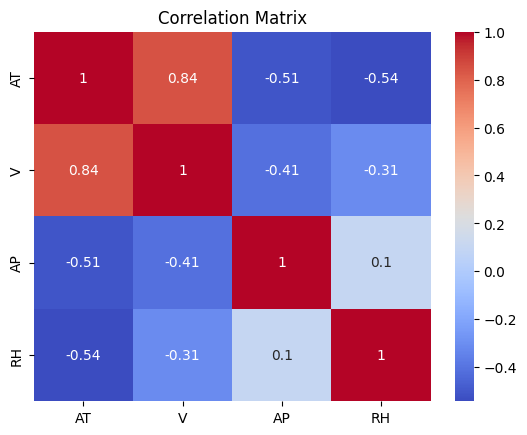

Variance Inflation Factor (VIF):
  Feature        VIF
0      AT  39.157705
1       V  74.969127
2      AP  66.618618
3      RH  40.704756

Q7c: Stepwise Regression for Feature Selection
Selected Features:
Index(['AT', 'V'], dtype='object')
RMSE with Selected Features: 4.95

Q7d: Polynomial Regression for Nonlinear Effects
Degree 1 - RMSE: 5.43
Degree 2 - RMSE: 5.20
Degree 3 - RMSE: 5.07
Degree 4 - RMSE: 5.07


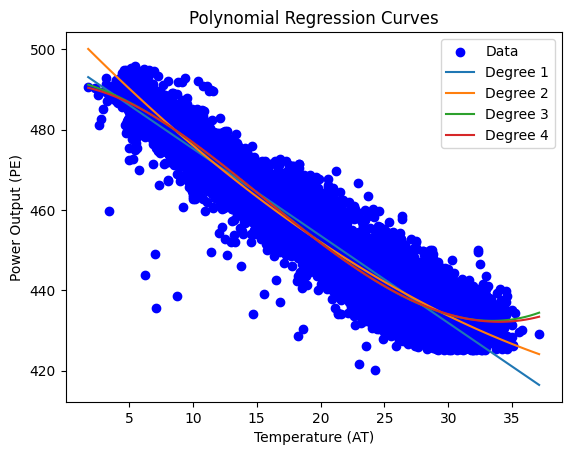


Q7e: Optimal Polynomial Degree using Cross-Validation
Degree 1 - Cross-validated RMSE: 5.43
Degree 2 - Cross-validated RMSE: 5.20
Degree 3 - Cross-validated RMSE: 5.07
Degree 4 - Cross-validated RMSE: 5.07
Optimal Polynomial Degree: 3

Analysis Complete!


In [35]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.feature_selection import RFE

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00294/CCPP.zip"
# Download and extract the dataset manually, then load it
power_plant = pd.read_excel("Folds5x2_pp.xlsx")

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
print(power_plant.head())

# Q7a: Multiple Linear Regression to Predict Power Output
print("\n" + "="*50)
print("Q7a: Multiple Linear Regression to Predict Power Output")
print("="*50)

# Prepare data
X = power_plant.drop('PE', axis=1)  # Predictors: Temperature, Ambient Pressure, Humidity, Exhaust Vacuum
y = power_plant['PE']  # Target: Power Output

# Fit multiple linear regression model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Evaluate model
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = model.score(X, y)
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

# Q7b: Correlation Matrix and Multicollinearity Analysis
print("\n" + "="*50)
print("Q7b: Correlation Matrix and Multicollinearity Analysis")
print("="*50)

# Compute correlation matrix
corr_matrix = X.corr()
print("Correlation Matrix:")
print(corr_matrix)

# Visualize correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Check for multicollinearity using VIF
vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("Variance Inflation Factor (VIF):")
print(vif)

# Q7c: Stepwise Regression for Feature Selection
print("\n" + "="*50)
print("Q7c: Stepwise Regression for Feature Selection")
print("="*50)

# Perform stepwise regression using Recursive Feature Elimination (RFE)
model_rfe = LinearRegression()
rfe = RFE(model_rfe, n_features_to_select=2)  # Select top 2 features
rfe.fit(X, y)
selected_features = X.columns[rfe.support_]
print("Selected Features:")
print(selected_features)

# Fit model with selected features
X_selected = X[selected_features]
model_selected = LinearRegression()
model_selected.fit(X_selected, y)
y_pred_selected = model_selected.predict(X_selected)
rmse_selected = np.sqrt(mean_squared_error(y, y_pred_selected))
print(f"RMSE with Selected Features: {rmse_selected:.2f}")

# Q7d: Polynomial Regression for Nonlinear Effects
print("\n" + "="*50)
print("Q7d: Polynomial Regression for Nonlinear Effects")
print("="*50)

# Prepare data
X_poly = power_plant[['AT']]  # Temperature as predictor
y_poly = power_plant['PE']

# Fit polynomial regression models
degrees = [1, 2, 3, 4]
results = {}

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_transformed = poly.fit_transform(X_poly)
    model_poly = LinearRegression()
    model_poly.fit(X_poly_transformed, y_poly)
    y_pred_poly = model_poly.predict(X_poly_transformed)
    rmse_poly = np.sqrt(mean_squared_error(y_poly, y_pred_poly))
    results[degree] = rmse_poly
    print(f"Degree {degree} - RMSE: {rmse_poly:.2f}")

# Plot polynomial regression curves
plt.scatter(X_poly, y_poly, color='blue', label='Data')
X_test = np.linspace(X_poly.min(), X_poly.max(), 100).reshape(-1, 1)

# Store models for each degree
models = {}

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_transformed = poly.fit_transform(X_poly)
    model_poly = LinearRegression()
    model_poly.fit(X_poly_transformed, y_poly)
    models[degree] = model_poly  # Store the model

# Now use the stored models for prediction in the plotting loop:
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_test = poly.fit_transform(X_test)
    # Use the correct model for prediction
    y_test = models[degree].predict(X_poly_test)
    plt.plot(X_test, y_test, label=f'Degree {degree}')

plt.xlabel('Temperature (AT)')
plt.ylabel('Power Output (PE)')
plt.title('Polynomial Regression Curves')
plt.legend()
plt.show()

# Q7e: Optimal Polynomial Degree using Cross-Validation
print("\n" + "="*50)
print("Q7e: Optimal Polynomial Degree using Cross-Validation")
print("="*50)

# Find optimal degree using cross-validation
best_degree = None
best_rmse = float('inf')

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_transformed = poly.fit_transform(X_poly)
    scores = cross_val_score(LinearRegression(), X_poly_transformed, y_poly, cv=5, scoring='neg_mean_squared_error')
    rmse_cv = np.sqrt(-scores.mean())
    if rmse_cv < best_rmse:
        best_rmse = rmse_cv
        best_degree = degree
    print(f"Degree {degree} - Cross-validated RMSE: {rmse_cv:.2f}")

print(f"Optimal Polynomial Degree: {best_degree}")

print("\n" + "="*50)
print("Analysis Complete!")
print("="*50)

Q8.
Electrical Grid Stability Dataset (Predicting Grid Stability)
Description: This dataset contains voltage, current, and power factor values to assess
electrical grid stability.
Linear Regression Questions:
a. Develop a multiple linear regression model to predict grid stability based on voltage
fluctuations.
b. Perform a residual analysis to check whether the errors are normally distributed.
c. Use regularization techniques (Ridge/Lasso) and compare performance with standard
linear regression.
Polynomial Regression Questions:
d. Fit a quadratic regression model to model nonlinear relationships between voltage and
stability index.
e. Compare the performance of linear vs. polynomial regression using Mean Absolute
Error (MAE) and Root Mean Squared Error (RMSE).

First 5 rows of the dataset:
       tau1      tau2      tau3      tau4        p1        p2        p3  \
0  2.959060  3.079885  8.381025  9.780754  3.763085 -0.782604 -1.257395   
1  9.304097  4.902524  3.047541  1.369357  5.067812 -1.940058 -1.872742   
2  8.971707  8.848428  3.046479  1.214518  3.405158 -1.207456 -1.277210   
3  0.716415  7.669600  4.486641  2.340563  3.963791 -1.027473 -1.938944   
4  3.134112  7.608772  4.943759  9.857573  3.525811 -1.125531 -1.845975   

         p4        g1        g2        g3        g4      stab     stabf  
0 -1.723086  0.650456  0.859578  0.887445  0.958034  0.055347  unstable  
1 -1.255012  0.413441  0.862414  0.562139  0.781760 -0.005957    stable  
2 -0.920492  0.163041  0.766689  0.839444  0.109853  0.003471  unstable  
3 -0.997374  0.446209  0.976744  0.929381  0.362718  0.028871  unstable  
4 -0.554305  0.797110  0.455450  0.656947  0.820923  0.049860  unstable  

Q8a: Multiple Linear Regression to Predict Grid Stability
RMSE: 0.37
MAE: 0

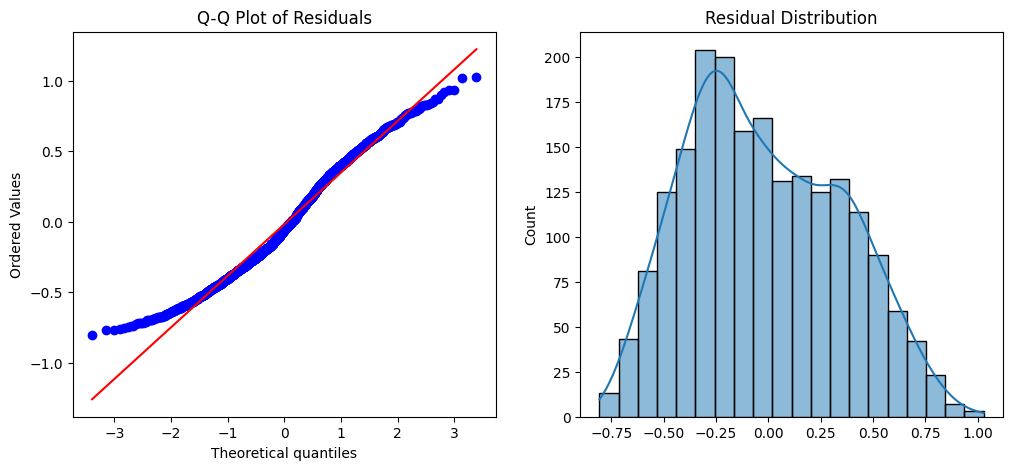


Q8c: Regularization Techniques (Ridge/Lasso)
Ridge Regression - RMSE: 0.37, MAE: 0.31
Lasso Regression - RMSE: 0.48, MAE: 0.46

Q8d: Quadratic Regression for Nonlinear Relationships
Quadratic Regression - RMSE: 0.45, MAE: 0.42


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


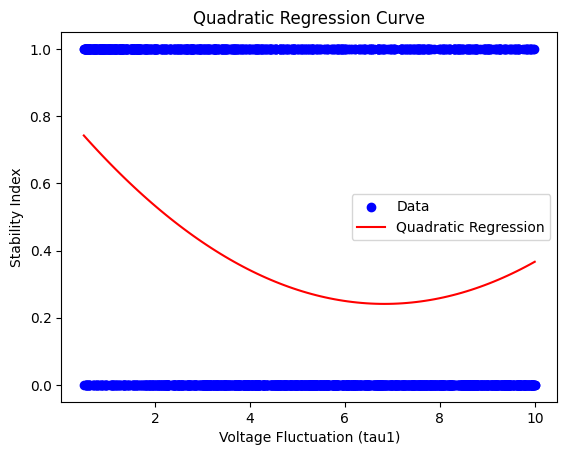


Q8e: Compare Linear vs. Polynomial Regression
Linear Regression - RMSE: 0.46, MAE: 0.43
Quadratic Regression - RMSE: 0.45, MAE: 0.42
Quadratic regression performs better based on RMSE.
Quadratic regression performs better based on MAE.

Analysis Complete!


In [36]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from scipy.stats import probplot

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00471/Data_for_UCI_named.csv"
grid_stability = pd.read_csv(url)

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
print(grid_stability.head())

# Clean the dataset (if necessary)
grid_stability.dropna(inplace=True)

# Q8a: Multiple Linear Regression to Predict Grid Stability
print("\n" + "="*50)
print("Q8a: Multiple Linear Regression to Predict Grid Stability")
print("="*50)

# Prepare data
X = grid_stability[['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4']]  # Predictors
y = grid_stability['stabf']  # Target (stability index)

# Convert target to numeric (if categorical)
y = pd.factorize(y)[0]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit multiple linear regression model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# Q8b: Residual Analysis
print("\n" + "="*50)
print("Q8b: Residual Analysis")
print("="*50)

# Calculate residuals
residuals = y_test - y_pred

# Check for normality using a Q-Q plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
probplot(residuals, plot=plt)
plt.title("Q-Q Plot of Residuals")

# Check for normality using a histogram
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# Q8c: Regularization Techniques (Ridge/Lasso)
print("\n" + "="*50)
print("Q8c: Regularization Techniques (Ridge/Lasso)")
print("="*50)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
print(f"Ridge Regression - RMSE: {rmse_ridge:.2f}, MAE: {mae_ridge:.2f}")

# Lasso Regression
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
print(f"Lasso Regression - RMSE: {rmse_lasso:.2f}, MAE: {mae_lasso:.2f}")

# Q8d: Quadratic Regression for Nonlinear Relationships
print("\n" + "="*50)
print("Q8d: Quadratic Regression for Nonlinear Relationships")
print("="*50)

# Prepare data
X_poly = grid_stability[['tau1']]  # Voltage fluctuation as predictor
y_poly = pd.factorize(grid_stability['stabf'])[0]  # Target (stability index)

# Split data into training and testing sets
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y_poly, test_size=0.2, random_state=42)

# Fit quadratic regression model
poly = PolynomialFeatures(degree=2)
X_train_poly_transformed = poly.fit_transform(X_train_poly)
X_test_poly_transformed = poly.transform(X_test_poly)
model_poly = LinearRegression()
model_poly.fit(X_train_poly_transformed, y_train_poly)
y_pred_poly = model_poly.predict(X_test_poly_transformed)

# Evaluate model
rmse_poly = np.sqrt(mean_squared_error(y_test_poly, y_pred_poly))
mae_poly = mean_absolute_error(y_test_poly, y_pred_poly)
print(f"Quadratic Regression - RMSE: {rmse_poly:.2f}, MAE: {mae_poly:.2f}")

# Plot quadratic regression curve
plt.scatter(X_test_poly, y_test_poly, color='blue', label='Data')
X_test_plot = np.linspace(X_test_poly.min(), X_test_poly.max(), 100).reshape(-1, 1)
X_test_plot_transformed = poly.transform(X_test_plot)
y_test_plot = model_poly.predict(X_test_plot_transformed)
plt.plot(X_test_plot, y_test_plot, color='red', label='Quadratic Regression')
plt.xlabel('Voltage Fluctuation (tau1)')
plt.ylabel('Stability Index')
plt.title('Quadratic Regression Curve')
plt.legend()
plt.show()

# Q8e: Compare Linear vs. Polynomial Regression
print("\n" + "="*50)
print("Q8e: Compare Linear vs. Polynomial Regression")
print("="*50)

# Fit linear regression model for comparison
model_linear = LinearRegression()
model_linear.fit(X_train_poly, y_train_poly)
y_pred_linear = model_linear.predict(X_test_poly)

# Evaluate linear regression model
rmse_linear = np.sqrt(mean_squared_error(y_test_poly, y_pred_linear))
mae_linear = mean_absolute_error(y_test_poly, y_pred_linear)
print(f"Linear Regression - RMSE: {rmse_linear:.2f}, MAE: {mae_linear:.2f}")

# Compare RMSE and MAE
print(f"Quadratic Regression - RMSE: {rmse_poly:.2f}, MAE: {mae_poly:.2f}")

if rmse_poly < rmse_linear:
    print("Quadratic regression performs better based on RMSE.")
else:
    print("Linear regression performs better based on RMSE.")

if mae_poly < mae_linear:
    print("Quadratic regression performs better based on MAE.")
else:
    print("Linear regression performs better based on MAE.")

print("\n" + "="*50)
print("Analysis Complete!")
print("="*50)

Q9.
Student Alcohol Consumption Dataset (Predicting Alcohol Use in High School
Students)
Description: This dataset contains demographic and lifestyle information about students,
along with their alcohol consumption levels.
Linear Regression Questions:
a. Create a multiple linear regression model to predict weekly alcohol consumption
based on age, study time, and family factors.
b. Assess the impact of parental education on student drinking habits using statistical
tests.
c. Evaluate the effect of interaction terms (e.g., age × peer influence) on alcohol
consumption.
Polynomial Regression Questions:
d. Fit a polynomial regression model to examine the non-linear relationship between
alcohol consumption and study time.
e. Compare R² values for different degrees of polynomial regression and interpret the
results.

First 5 rows of the dataset:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]

Q9a: Multiple Linear Regression to Predict Weekly Alcohol 

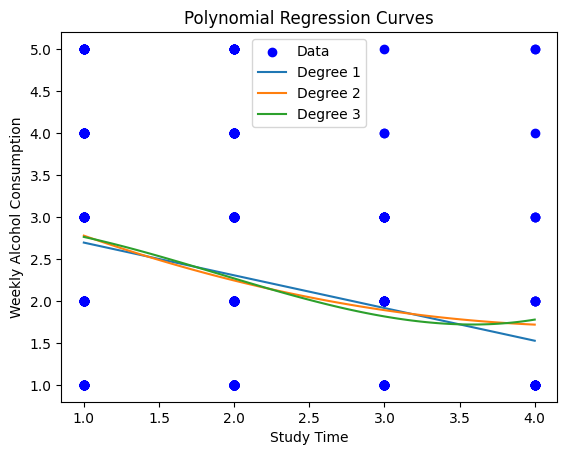


Q9e: Compare R² Values for Different Polynomial Degrees


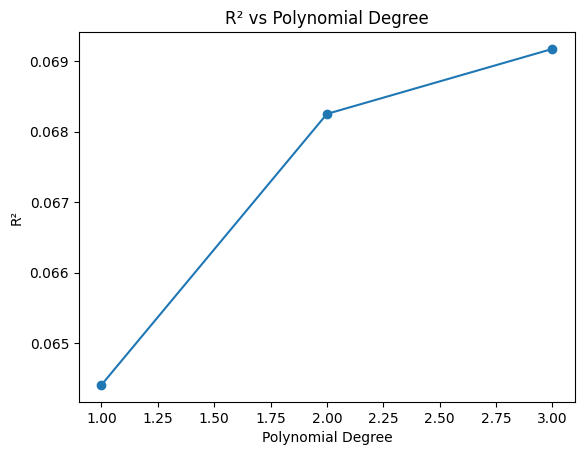

Higher R² values indicate better model fit. However, higher-degree polynomials may lead to overfitting.

Analysis Complete!


In [37]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00356/student.zip"
# Download and extract the dataset manually, then load it
student = pd.read_csv("student-mat.csv", sep=';')

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
print(student.head())

# Q9a: Multiple Linear Regression to Predict Weekly Alcohol Consumption
print("\n" + "="*50)
print("Q9a: Multiple Linear Regression to Predict Weekly Alcohol Consumption")
print("="*50)

# Prepare data
X = student[['age', 'studytime', 'famrel', 'Medu', 'Fedu']]  # Predictors: Age, Study Time, Family Relationships, Parental Education
y = student['Walc']  # Target: Weekly Alcohol Consumption

# Fit multiple linear regression model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Evaluate model
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

# Q9b: Impact of Parental Education on Drinking Habits
print("\n" + "="*50)
print("Q9b: Impact of Parental Education on Drinking Habits")
print("="*50)

# Perform ANOVA to assess the impact of parental education
model_anova = ols('Walc ~ C(Medu) + C(Fedu)', data=student).fit()
anova_table = sm.stats.anova_lm(model_anova, typ=2)
print("ANOVA Table:")
print(anova_table)

# Q9c: Interaction Terms in Alcohol Consumption
print("\n" + "="*50)
print("Q9c: Interaction Terms in Alcohol Consumption")
print("="*50)

# Add interaction term: Age × Peer Influence (assuming 'goout' represents peer influence)
student['age_goout'] = student['age'] * student['goout']

# Fit model with interaction term
X_interaction = student[['age', 'goout', 'age_goout']]
model_interaction = LinearRegression()
model_interaction.fit(X_interaction, y)
y_pred_interaction = model_interaction.predict(X_interaction)

# Evaluate model with interaction term
rmse_interaction = np.sqrt(mean_squared_error(y, y_pred_interaction))
r2_interaction = r2_score(y, y_pred_interaction)
print(f"RMSE with Interaction Term: {rmse_interaction:.2f}")
print(f"R² with Interaction Term: {r2_interaction:.2f}")

# Q9d: Polynomial Regression for Non-linear Relationship
print("\n" + "="*50)
print("Q9d: Polynomial Regression for Non-linear Relationship")
print("="*50)

# Prepare data
X_poly = student[['studytime']]  # Study Time as predictor
y_poly = student['Walc']

# Fit polynomial regression models
degrees = [1, 2, 3]
results = {}
models = {}  # Store models for each degree

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_transformed = poly.fit_transform(X_poly)
    model_poly = LinearRegression()
    model_poly.fit(X_poly_transformed, y_poly)
    y_pred_poly = model_poly.predict(X_poly_transformed)
    rmse_poly = np.sqrt(mean_squared_error(y_poly, y_pred_poly))
    r2_poly = r2_score(y_poly, y_pred_poly)
    results[degree] = {'RMSE': rmse_poly, 'R²': r2_poly}
    models[degree] = model_poly  # Store the model for this degree
    print(f"Degree {degree} - RMSE: {rmse_poly:.2f}, R²: {r2_poly:.2f}")

# Plot polynomial regression curves
plt.scatter(X_poly, y_poly, color='blue', label='Data')
X_test = np.linspace(X_poly.min(), X_poly.max(), 100).reshape(-1, 1)
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_test = poly.fit_transform(X_test)

    # Use the correct model for prediction
    y_test = models[degree].predict(X_poly_test)

    plt.plot(X_test, y_test, label=f'Degree {degree}')

plt.xlabel('Study Time')
plt.ylabel('Weekly Alcohol Consumption')
plt.title('Polynomial Regression Curves')
plt.legend()
plt.show()

# Q9e: Compare R² Values for Different Polynomial Degrees
print("\n" + "="*50)
print("Q9e: Compare R² Values for Different Polynomial Degrees")
print("="*50)

# Compare R² values
degrees_list = list(results.keys())
r2_list = [results[d]['R²'] for d in degrees_list]

plt.plot(degrees_list, r2_list, marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('R²')
plt.title('R² vs Polynomial Degree')
plt.show()

print("Higher R² values indicate better model fit. However, higher-degree polynomials may lead to overfitting.")

print("\n" + "="*50)
print("Analysis Complete!")
print("="*50)

Q10.
Insurance Charges Dataset (Predicting Medical Insurance Costs)
Description: This dataset contains information about insurance policyholders, such as age,
BMI, and smoking habits, along with insurance charges.
Linear Regression Questions:
a. Develop a linear regression model to predict insurance charges based on patient
characteristics.
b. Identify the most important predictor of insurance cost using feature importance
ranking.
c. Perform an F-test to check whether at least one predictor variable significantly
impacts insurance charges.
Polynomial Regression Questions:
d. Fit a polynomial regression model to analyze the relationship between BMI and
insurance cost.
e. Use grid search to optimize the degree of the polynomial regression model.

First 5 rows of the dataset:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Q10a: Linear Regression to Predict Insurance Charges
RMSE: 6042.03
R²: 0.75

Q10b: Feature Importance Ranking
Feature Importance (Coefficients):
smoker_yes          23836.300502
children              474.566470
bmi                   338.664638
age                   256.973582
region_northwest     -352.182112
region_southwest     -959.374674
region_southeast    -1034.360127
dtype: float64

Q10c: F-test for Significance of Predictors
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                     

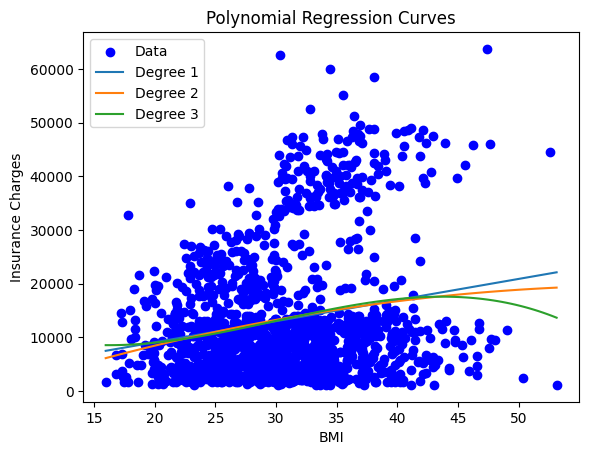


Q10e: Grid Search for Optimal Polynomial Degree
Optimal Polynomial Degree: 1
Best RMSE: 11870.63

Analysis Complete!


In [39]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
from scipy.stats import f

# Load the dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
insurance = pd.read_csv(url)

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
print(insurance.head())

# Q10a: Linear Regression to Predict Insurance Charges
print("\n" + "="*50)
print("Q10a: Linear Regression to Predict Insurance Charges")
print("="*50)

# Prepare data
X = insurance[['age', 'bmi', 'children', 'smoker', 'region']]  # Predictors
y = insurance['charges']  # Target: Insurance Charges

# One-hot encode categorical variables
encoder = OneHotEncoder(drop='first')
X_encoded = encoder.fit_transform(X[['smoker', 'region']]).toarray()
X_encoded_df = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(['smoker', 'region']))
X_final = pd.concat([X[['age', 'bmi', 'children']], X_encoded_df], axis=1)

# Fit linear regression model
model = LinearRegression()
model.fit(X_final, y)
y_pred = model.predict(X_final)

# Evaluate model
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = model.score(X_final, y)
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

# Q10b: Feature Importance Ranking
print("\n" + "="*50)
print("Q10b: Feature Importance Ranking")
print("="*50)

# Extract coefficients
coefficients = pd.Series(model.coef_, index=X_final.columns)
print("Feature Importance (Coefficients):")
print(coefficients.sort_values(ascending=False))

# Q10c: F-test for Significance of Predictors
print("\n" + "="*50)
print("Q10c: F-test for Significance of Predictors")
print("="*50)

# Fit linear regression using statsmodels for F-test
X_sm = sm.add_constant(X_final)  # Add intercept term
model_sm = sm.OLS(y, X_sm).fit()
print(model_sm.summary())

# Extract F-statistic and p-value
f_statistic = model_sm.fvalue
p_value = model_sm.f_pvalue
print(f"F-statistic: {f_statistic:.2f}, P-value: {p_value:.4f}")
if p_value < 0.05:
    print("At least one predictor significantly impacts insurance charges.")
else:
    print("No predictor significantly impacts insurance charges.")

# Q10d: Polynomial Regression for BMI and Insurance Cost
print("\n" + "="*50)
print("Q10d: Polynomial Regression for BMI and Insurance Cost")
print("="*50)

# Prepare data
X_poly = insurance[['bmi']]  # Predictor: BMI
y_poly = insurance['charges']

# Fit polynomial regression models
degrees = [1, 2, 3]
results = {}
models = {}  # Store models for each degree

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_transformed = poly.fit_transform(X_poly)
    model_poly = LinearRegression()
    model_poly.fit(X_poly_transformed, y_poly)
    y_pred_poly = model_poly.predict(X_poly_transformed)
    rmse_poly = np.sqrt(mean_squared_error(y_poly, y_pred_poly))
    results[degree] = rmse_poly
    models[degree] = model_poly  # Store the model for this degree
    print(f"Degree {degree} - RMSE: {rmse_poly:.2f}")

# Plot polynomial regression curves
plt.scatter(X_poly, y_poly, color='blue', label='Data')
X_test = np.linspace(X_poly.min(), X_poly.max(), 100).reshape(-1, 1)
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_test = poly.fit_transform(X_test)

    # Use the correct model for prediction (from the 'models' dictionary)
    y_test = models[degree].predict(X_poly_test)

    plt.plot(X_test, y_test, label=f'Degree {degree}')

plt.xlabel('BMI')
plt.ylabel('Insurance Charges')
plt.title('Polynomial Regression Curves')
plt.legend()
plt.show()

# Q10e: Grid Search for Optimal Polynomial Degree
print("\n" + "="*50)
print("Q10e: Grid Search for Optimal Polynomial Degree")
print("="*50)

# Define pipeline
pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('reg', LinearRegression())
])

# Define parameter grid
param_grid = {'poly__degree': [1, 2, 3, 4, 5]}

# Perform grid search
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_poly, y_poly)

# Extract best degree
best_degree = grid_search.best_params_['poly__degree']
best_rmse = np.sqrt(-grid_search.best_score_)
print(f"Optimal Polynomial Degree: {best_degree}")
print(f"Best RMSE: {best_rmse:.2f}")

print("\n" + "="*50)
print("Analysis Complete!")
print("="*50)